In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 82.2 MB/s eta 0:00:00


Load and Preprocess Iris

We scale the features to in a range suitable for angle embedding, and also one-hot encode the labels for the cross-entropy loss.
I am not sure if it fully needed, but I am seeing multiple accounts of this.

In [13]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X = iris.data          # 150 samples, 4 features
y = iris.target.reshape(-1, 1)  # 0,1,2

# Scale features to [0, π] for angle embedding
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# StandardScaler gives mean 0, std 1; we map to [0, π] via a sigmoid-like scaling
X_scaled = 1 / (1 + np.exp(-X_scaled)) * np.pi   # maps to (0, π)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y
)

We use 4 qubits, one per feature for the encoding. The encoding is angle embedding. Apply an RY rotation gate with angle equal to the feature value on each qubit as is custormary in machine learning usually. After encoding we apply fixed random sequence of gates that entangle qubits using CNOT gates.

In [17]:
#Fixed high-dimensional nonlinear dynamical system
# this part is not trained : The reservoir is not trained.
#

n_qubits = 4
np.random.seed(42)
# Random parameters for the reservoir (frozen)
reservoir_weights = np.random.random(n_qubits * 3) * 2 * np.pi  # example: 12 params

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface='torch')
def reservoir_circuit(x, weights):
    # Encode the 4 features into the qubits (RY rotations)
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

    # Fixed random dynamics
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    qml.RY(weights[2], wires=2)
    qml.RY(weights[3], wires=3) #these are the encoding dynamics

    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[2, 3])

    qml.RZ(weights[4], wires=0)
    qml.RZ(weights[5], wires=1)
    qml.RZ(weights[6], wires=2)
    qml.RZ(weights[7], wires=3)

    qml.CNOT(wires=[1, 2]) # these are for entanglement dynamics
    qml.CNOT(wires=[3, 0])

    # Measure PauliZ on each qubit → reservoir state vector of length n_qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [18]:
# Example input to visualize structure
sample_x = torch.tensor(X_train[0], dtype=torch.float32)
sample_w = torch.tensor(reservoir_weights, dtype=torch.float32)

print(qml.draw(reservoir_circuit)(sample_x, sample_w))

0: ──RY(0.47)──RY(2.35)─╭●──RZ(0.98)────╭X─┤  <Z>
1: ──RY(1.29)──RY(5.97)─╰X──RZ(0.98)─╭●─│──┤  <Z>
2: ──RY(0.65)──RY(4.60)─╭●──RZ(0.36)─╰X─│──┤  <Z>
3: ──RY(0.66)──RY(3.76)─╰X──RZ(5.44)────╰●─┤  <Z>


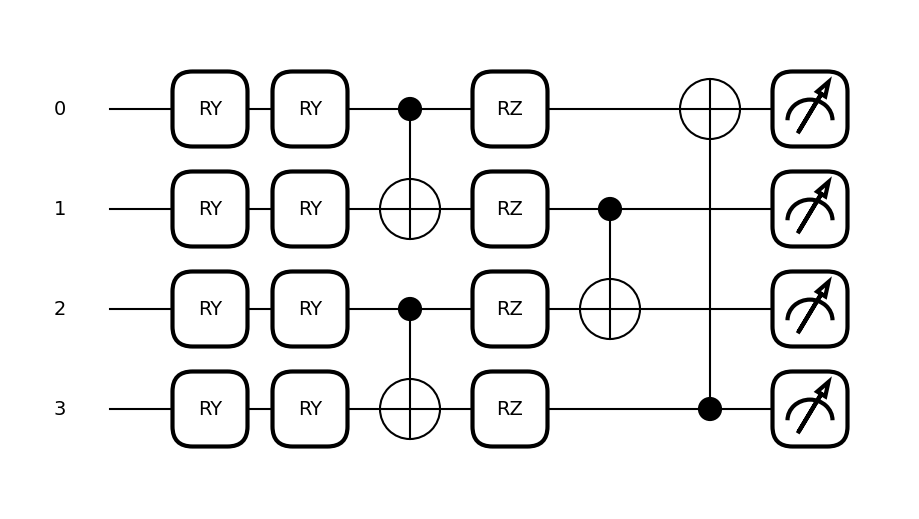

In [19]:
import matplotlib.pyplot as plt

fig, ax = qml.draw_mpl(reservoir_circuit)(sample_x, sample_w)
plt.show()

In [20]:
def extract_features(X, weights):
    X_t = torch.tensor(X, dtype=torch.float32)
    W_t = torch.tensor(weights, dtype=torch.float32)

    features = []
    for x in X_t:
        features.append(torch.stack(reservoir_circuit(x, W_t)))

    return torch.stack(features).detach().numpy()

In [22]:
# def extract_features(X, weights):
#     features = []
#     for i in range(X.shape[0]):
#         state = reservoir_circuit(torch.tensor(X[i], dtype=torch.float32),
#                                   torch.tensor(weights, dtype=torch.float32))
#         features.append(state.detach().numpy())
#     return np.array(features)

X_train_res = extract_features(X_train, reservoir_weights)
X_test_res  = extract_features(X_test, reservoir_weights)

class Readout(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)
#This is the classical training; we train a linear classifier on the features extracted from the quantum reservoir. The quantum circuit
#The quantum circuit is not involved in this training; its parameters are frozen

input_dim = n_qubits
output_dim = 3 #iris has 3 classes
model = Readout(input_dim, output_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# Convert to torch tensors
X_train_t = torch.tensor(X_train_res, dtype=torch.float32)
y_train_t = torch.tensor(np.argmax(y_train, axis=1), dtype=torch.long)  # class indices

X_test_t  = torch.tensor(X_test_res, dtype=torch.float32)
y_test_t  = torch.tensor(np.argmax(y_test, axis=1), dtype=torch.long)

# Training loop
epochs = 10000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t) #loss computation
    loss.backward() #backward pass
    optimizer.step()

    if epoch % 250 == 0:
        print(f"Epoch {epoch:3d}, Loss: {loss.item():.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    train_pred = torch.argmax(model(X_train_t), dim=1)
    test_pred  = torch.argmax(model(X_test_t), dim=1)
    train_acc = accuracy_score(y_train_t.numpy(), train_pred.numpy())
    test_acc  = accuracy_score(y_test_t.numpy(), test_pred.numpy())

print(f"\nTrain accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Epoch   0, Loss: 1.1141
Epoch 250, Loss: 0.3549
Epoch 500, Loss: 0.3128
Epoch 750, Loss: 0.2927
Epoch 1000, Loss: 0.2816
Epoch 1250, Loss: 0.2749
Epoch 1500, Loss: 0.2708
Epoch 1750, Loss: 0.2683
Epoch 2000, Loss: 0.2669
Epoch 2250, Loss: 0.2660
Epoch 2500, Loss: 0.2654
Epoch 2750, Loss: 0.2650
Epoch 3000, Loss: 0.2648
Epoch 3250, Loss: 0.2646
Epoch 3500, Loss: 0.2645
Epoch 3750, Loss: 0.2644
Epoch 4000, Loss: 0.2644
Epoch 4250, Loss: 0.2643
Epoch 4500, Loss: 0.2642
Epoch 4750, Loss: 0.2642
Epoch 5000, Loss: 0.2642
Epoch 5250, Loss: 0.2642
Epoch 5500, Loss: 0.2642
Epoch 5750, Loss: 0.2641
Epoch 6000, Loss: 0.2641
Epoch 6250, Loss: 0.2641
Epoch 6500, Loss: 0.2641
Epoch 6750, Loss: 0.2641
Epoch 7000, Loss: 0.2641
Epoch 7250, Loss: 0.2641
Epoch 7500, Loss: 0.2641
Epoch 7750, Loss: 0.2641
Epoch 8000, Loss: 0.2641
Epoch 8250, Loss: 0.2641
Epoch 8500, Loss: 0.2641
Epoch 8750, Loss: 0.2641
Epoch 9000, Loss: 0.2641
Epoch 9250, Loss: 0.2641
Epoch 9500, Loss: 0.2641
Epoch 9750, Loss: 0.2641

Tra